# Exploratory Data Analysis of the HMDA Dataset (2007 - 2017)

In this notebook, I analyse basic trends to get a better understanding of the HMDA dataset.

In [1]:
# Libraries

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.ticker import StrMethodFormatter

In [2]:
os.getcwd()
os.chdir("../data/processed")

In [3]:
# Import data set
hmda = pd.read_csv("cleaned_missing.csv", index_col=0)

## 1. Continuous variable exploration

The variables are: income_000s, loan_amount_000s, tract_to_msamd_income

### A. Income

The max income is  60,789,000.0
The min income is  1,000.0


(0.0, 2000.0)

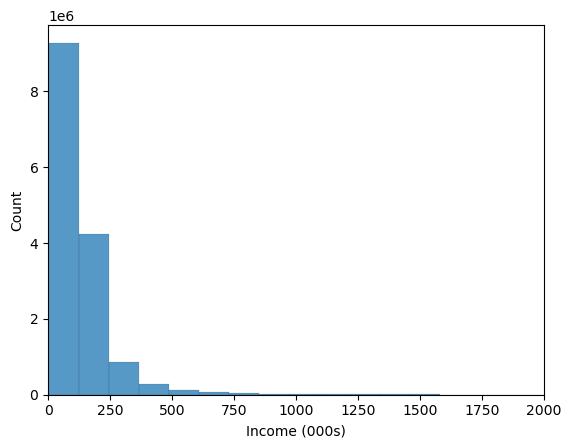

In [4]:
# There are clearly outliers in the dataset
max_income = hmda['income_000s'].max() * 1000
print("The max income is", f'{max_income: ,}') # 60,789,000 is the max income!

min_income = hmda['income_000s'].min() * 1000
print("The min income is", f'{min_income: ,}') # 1,000 is the min income, which makes sense.

# Define a reasonable range to view
ax = sns.histplot(data=hmda, x="income_000s", bins=500)
ax.set(xlabel = "Income (000s)", ylabel = "Count")
ax.set_xlim(0, 2000)

[Text(0.5, 0, 'Log Income (000s)'), Text(0, 0.5, 'Count')]

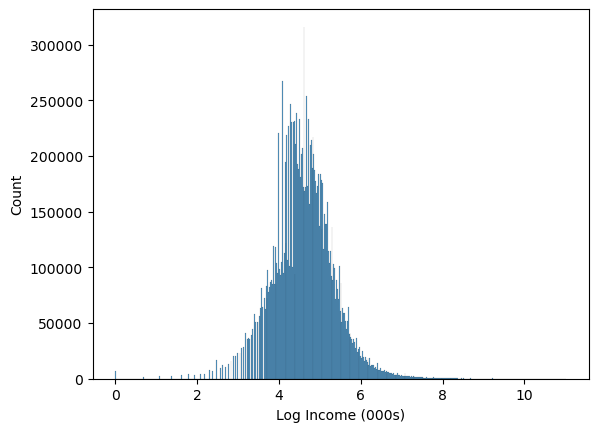

In [5]:
# Apply log transformation to the loan data
income_df = hmda[['income_000s']]
log_income = np.log(income_df)

# Plot
ax = sns.histplot(data = log_income, x = "income_000s", bins = 500)
ax.set(xlabel = "Log Income (000s)", ylabel = "Count")

Given that there are clear outliers on the right end, I set the maximum plausible income to log_income_000s = 8.5, which corresponds to around $5 million (per year). While there may genuinely be people earning more than this amount per year, this is a reasonable number that allows for extremely high incomes while not allowing nonsensical outliers. There are no clear outliers on the left side (as minimum income is still reasonable at $1000), so I only drop values where income is greater than $5 million.

In [6]:
# Calculate instances of outlier rows
count_outlier_income = (hmda['income_000s'] > 5000).sum()
pct_outlier_income = round(count_outlier_income/len(hmda) * 100, 2) 

print("The number of outlier rows is", f'{count_outlier_income: ,}', ", which is", f'{pct_outlier_income}', "%.")

# Drop instances of outlier rows
hmda = hmda.loc[hmda['income_000s'] <= 5000]

The number of outlier rows is  3,923 , which is 0.03 %.


### B. Loan amount

The max loan is  475,000,000.0
The min loan is  1,000.0


(0.0, 2000.0)

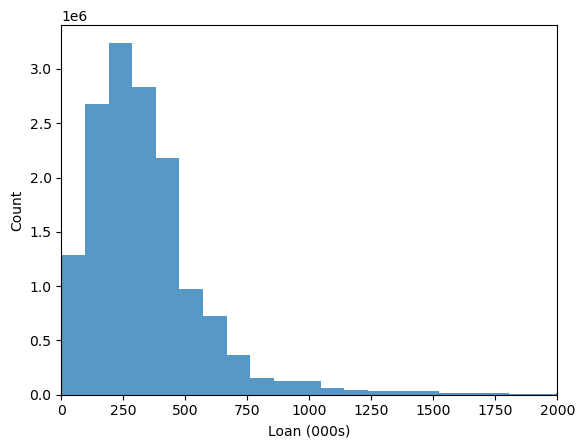

In [7]:
# There are clearly outliers in the dataset
max_loan = hmda['loan_amount_000s'].max() * 1000
print("The max loan is", f'{max_loan: ,}') # 475 million is the max loan!

min_loan = hmda['loan_amount_000s'].min() * 1000
print("The min loan is", f'{min_loan: ,}') # 1,000 is the min loan, which makes sense.

# Define a reasonable range to view
ax = sns.histplot(data=hmda, x="loan_amount_000s", bins=5000)
ax.set(xlabel = "Loan (000s)", ylabel = "Count")
ax.set_xlim(0, 2000)

[Text(0.5, 0, 'Log Loan (000s)'), Text(0, 0.5, 'Count')]

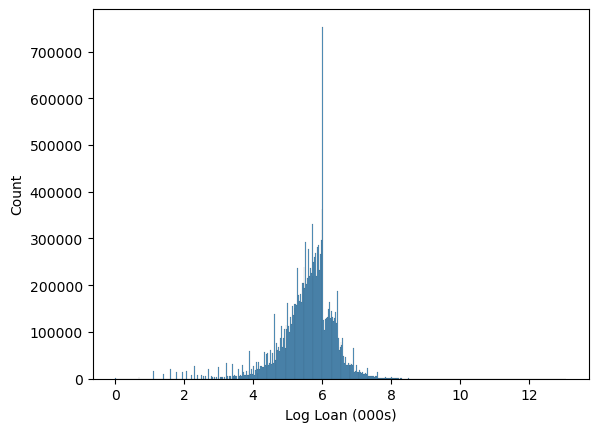

In [8]:
# Apply log transformation to the loan data
loan_df = hmda[['loan_amount_000s']]
log_loan = np.log(loan_df)

# Plot
ax = sns.histplot(data = log_loan, x = "loan_amount_000s", bins = 500)
ax.set(xlabel = "Log Loan (000s)", ylabel = "Count")

In [9]:
# Examine the spike
# Extract the data
x = log_loan["loan_amount_000s"]

# Compute histogram with same number of bins as seaborn
counts, bin_edges = np.histogram(x, bins=500)

# Find the tallest bin
max_idx = np.argmax(counts)

# Bin information
x_left = bin_edges[max_idx]
x_right = bin_edges[max_idx + 1]
x_center = (x_left + x_right) / 2
y_value = counts[max_idx]

print(f"Peak bin:")
print(f"Center = {x_center}")
print(f"Count = {y_value}")

Peak bin:
Center = 6.025763308270735
Count = 753043


The peak at around 6.03 corresponds to around $417,000. This amount is the "conforming loan limit", i.e. the maximum size loan Fannie Mae and Freddie Mac would purchase, as it is easy to sell off. Loan requests just above that limit are shifted down to the conforming loan limit to get better interest rates. This is not an error of the data, but rather a facet of the loan market. This is why, just to the right of the peak, there is a sharp drop before increasing again.

Once again, there are clear outliers and I set all maximum loans to $5 million, which maintains a very high loan amount while getting rid of outliers.

In [10]:
# Calculate instances of outlier rows
count_outlier_loan = (hmda['loan_amount_000s'] > 5000).sum()
pct_outlier_loan = round(count_outlier_loan/len(hmda) * 100, 2) 

print("The number of outlier rows is", f'{count_outlier_loan: ,}', ", which is", f'{pct_outlier_loan}', "%.")

# Drop instances of outlier rows
hmda = hmda.loc[hmda['loan_amount_000s'] <= 5000]

The number of outlier rows is  2,423 , which is 0.02 %.


### C. Tract to MSA/MD income

The max ratio is  430.03
The min ratio is  0.0


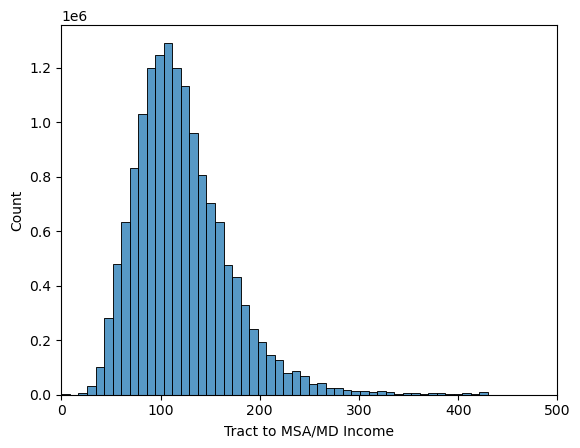

In [11]:
# Check for signs of outliers
max_ratio = round(hmda['tract_to_msamd_income'].max(),2)
print("The max ratio is", f'{max_ratio: ,}')

min_ratio = hmda['tract_to_msamd_income'].min()
print("The min ratio is", f'{min_ratio: ,}')

# Define a reasonable range to view
plt.clf()
ax = sns.histplot(data = hmda, x = "tract_to_msamd_income", bins=50)
ax.set(xlabel = "Tract to MSA/MD Income", ylabel = "Count")
ax.set_xlim(0, 500)

# Drop instances of outlier rows
hmda = hmda.loc[hmda['tract_to_msamd_income'] != 0]

The distribution is centered around 100 (i.e. 100%), which is what we would expect given that the variable tells us the ratio of the person's income compared to the average in the county.

There are instances where the tract to MSA/MD income is 0, suggesting that the person has no income when applying for the loan. This is likely not an outlier.

To calculate whether there are outliers on the right-hand-side of the histogram, I use Tukey's method, which says that all values outside the interval of [Lower quartile - 1.5 * IQR, Upper quartile + 1.5 * IQR] (where IQR is the inter-quartile range) are outliers.

In [12]:
quartiles = hmda['tract_to_msamd_income'].quantile([0.25, 0.75])
iqr = quartiles[0.75] - quartiles[0.25]

lower_bound = quartiles[0.25] - 1.5*iqr
upper_bound = quartiles[0.75] + 1.5*iqr

print("The lower bound is", round(lower_bound, 2))
print("The upper bound is", round(upper_bound, 2))

The lower bound is 1.73
The upper bound is 233.6


The upper bound still cuts off a significant tail, and incomes of 450 times the average is not implausible in California. I do not drop outliers, but I still log-transform the data for consistency.

(0.0, 10.0)

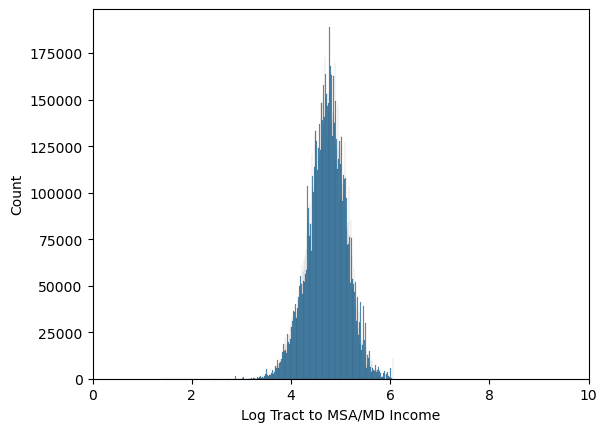

In [13]:
# Apply log transformation to the tract to MSA/MD income data
ratio_df = hmda[['tract_to_msamd_income']]
log_ratio = np.log(ratio_df)

# Plot
ax = sns.histplot(data = log_ratio, x = "tract_to_msamd_income", bins = 500)
ax.set(xlabel = "Log Tract to MSA/MD Income", ylabel = "Count")
ax.set_xlim(0, 10)

### D. Final log-transformed categorical variables

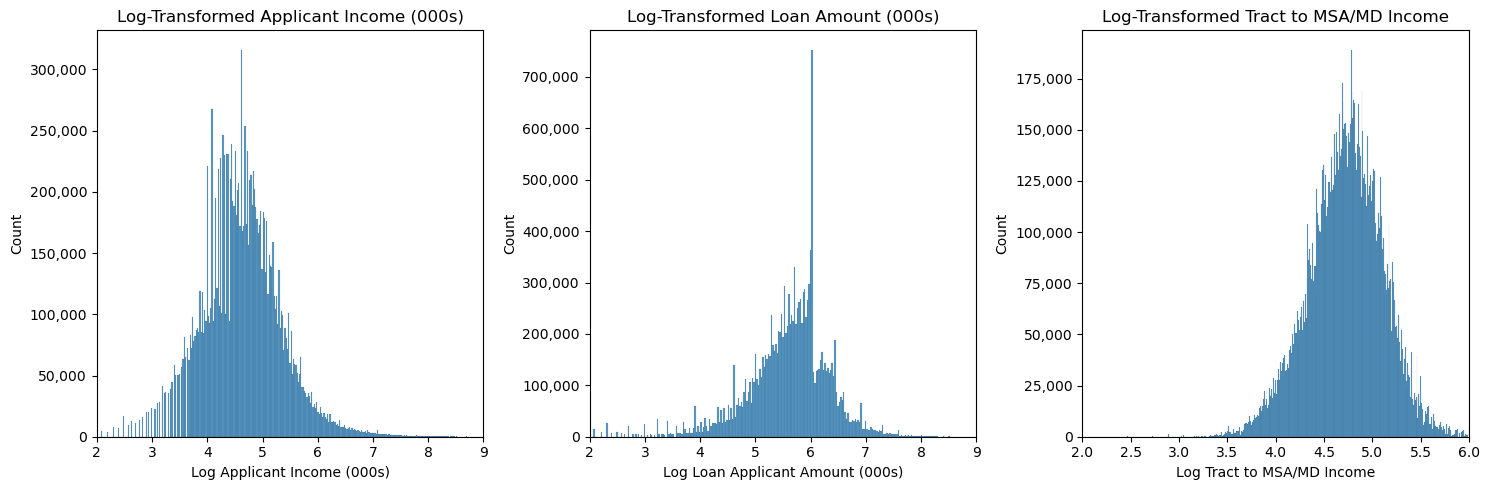

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data = log_income, x = "income_000s", bins = 500, ax = axes[0])
axes[0].set(xlabel = "Log Applicant Income (000s)", ylabel = "Count")
axes[0].set_xlim(2, 9)
axes[0].set_title("Log-Transformed Applicant Income (000s)")

sns.histplot(data = log_loan, x = "loan_amount_000s", bins = 500, ax = axes[1])
axes[1].set(xlabel = "Log Loan Applicant Amount (000s)", ylabel = "Count")
axes[1].set_xlim(2, 9)
axes[1].set_title("Log-Transformed Loan Amount (000s)")

sns.histplot(data = log_ratio, x = "tract_to_msamd_income", bins = 500, ax = axes[2])
axes[2].set(xlabel = "Log Tract to MSA/MD Income", ylabel = "Count")
axes[2].set_xlim(2, 6)
axes[2].set_title("Log-Transformed Tract to MSA/MD Income")

# Add comma separators to all y-axes
for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

I do not repeat the exercise for each year, as (1) outlier decisions are generously high, and there will be no years that have outliers past this number; (2) the central limit theorem reassures me that for each year the data will still look roughly log-normal; and (3) year-by-year exploration of the dataset is more suited to analysis stage, when "real-time" data begin arriving.

### E. Examining the "conforming loan spike" by year

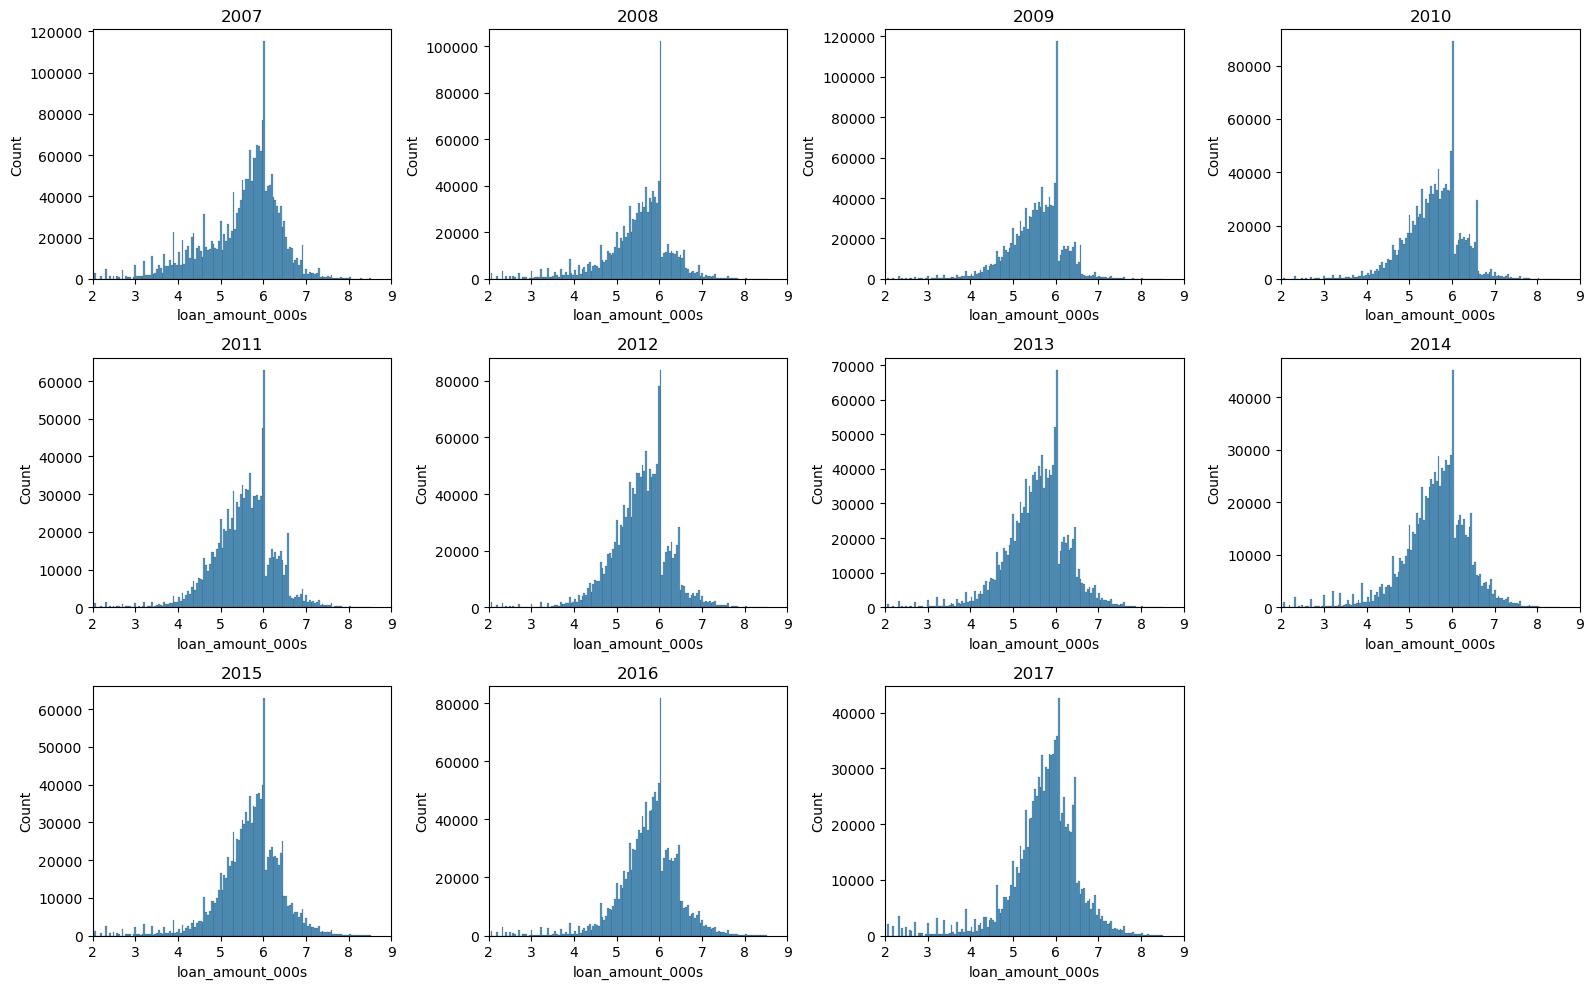

In [15]:
# Create a loop that shows the spikes by year

years = range(2007, 2018)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, year in enumerate(years):

    x = hmda.loc[hmda['year'] == year]
    log_loan = np.log(x['loan_amount_000s'])

    sns.histplot(
        x=log_loan,
        bins=200,
        ax=axes[i]
    )

    axes[i].set_title(str(year))
    axes[i].set_xlim(2, 9)

# Remove the unused 12th subplot
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

In [16]:
# Create a dataframe that shows the value of the spikes

results = []

for year in range(2007, 2018):

    # Filter to year
    x = hmda.loc[hmda['year'] == year, 'loan_amount_000s']

    # Log transform
    log_loan = np.log(x)

    # Histogram
    counts, bin_edges = np.histogram(log_loan, bins=500)

    # Peak bin
    max_idx = np.argmax(counts)

    x_left = bin_edges[max_idx]
    x_right = bin_edges[max_idx + 1]
    x_center = (x_left + x_right) / 2

    results.append({
        'Year': year,
        'Peak log loan': round(x_left, 2),
    })

# Display results

peak_df = pd.DataFrame(results)

# Convert to real (not log) values
peak_df["Peak loan (USD)"] = round(np.exp(peak_df["Peak log loan"]) * 1000, 2)

# Comparison with real conforming loan limits
conforming_loan_limits = [417000] * 10
conforming_loan_limits.append(424000)
peak_df["Conforming loan limits (USD)"] = conforming_loan_limits

peak_df.style.format({
    "Peak loan (USD)": "{:,.2f}",
    "Conforming loan limits (USD)": "{:,.2f}"
})

,Year,Peak log loan,Peak loan (USD),Conforming loan limits (USD)
0,2007,6.030000,"415,715.03","417,000.00"
1,2008,6.030000,"415,715.03","417,000.00"
2,2009,6.030000,"415,715.03","417,000.00"
3,2010,6.030000,"415,715.03","417,000.00"
4,2011,6.030000,"415,715.03","417,000.00"
5,2012,6.030000,"415,715.03","417,000.00"
6,2013,6.030000,"415,715.03","417,000.00"
7,2014,6.030000,"415,715.03","417,000.00"
8,2015,6.030000,"415,715.03","417,000.00"
9,2016,6.030000,"415,715.03","417,000.00"


This matches the pattern given by the US Government (https://www.fhfa.gov/blog/insights/the-dynamics-of-fhfa-conforming-loan-limits-and-house-prices). Any differences are due to binning amounts.

### F. Adjusting the dataset to only have log-values of continuous variables

In [17]:
# Create log-transformed vars
hmda['log_income_000s'] = np.log(hmda['income_000s'])
hmda['log_loan_amount_000s'] = np.log(hmda['loan_amount_000s'])
hmda['log_tract_to_msamd_income'] = np.log(hmda['tract_to_msamd_income'])

# Drop non log-transformed vars
hmda = hmda.drop(columns = ['income_000s', 'loan_amount_000s', 'tract_to_msamd_income'])

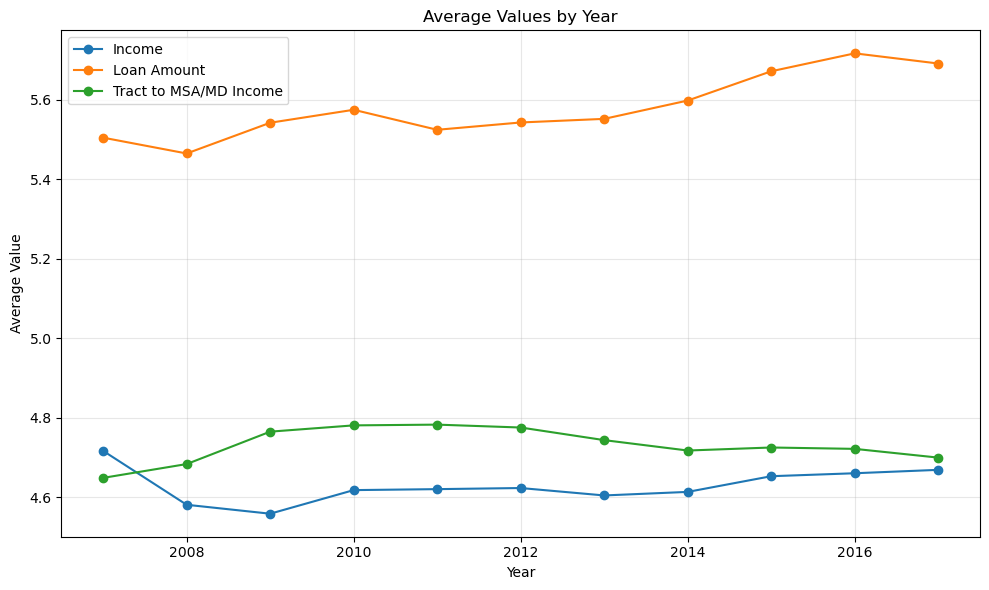

In [18]:
# Plot continuous variables by year

# Calculate yearly averages
yearly = (
    hmda.groupby("year")
    .agg({
        "log_income_000s": "mean",
        "log_loan_amount_000s": "mean",
        "log_tract_to_msamd_income": "mean"
    })
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    yearly["year"],
    yearly["log_income_000s"],
    marker="o",
    label="Income"
)

plt.plot(
    yearly["year"],
    yearly["log_loan_amount_000s"],
    marker="o",
    label="Loan Amount"
)

plt.plot(
    yearly["year"],
    yearly["log_tract_to_msamd_income"],
    marker="o",
    label="Tract to MSA/MD Income"
)

plt.title("Average Values by Year")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Categorical variable exploration

The variables are: action_taken, race, sex, ethnicity, loan_type, lien_status

### A. Action taken

In [19]:
# Check action categories
hmda.groupby("action_taken").size()

action_taken
1    10377769
2     1116161
3     3521849
dtype: int64

1 indicates that the loan was approved and the borrower accepted it. 2 indicates that the loan was approved but the borrower did not accept it. 3 indicates that the loan was denied.

As I plan to run a logistic regression, I will create a new category "action_taken_clean", where 1 and 2 indicate that the loan was approved and 3 indicates that the loan was denied.

In [20]:
# Create a new action taken variable that is binary
hmda['action_taken_old'] = hmda['action_taken']

# Replace instances of 2 with 1 and rename 3 as 2
hmda.loc[hmda['action_taken_old'] == 2, 'action_taken'] = 1
hmda.loc[hmda['action_taken_old'] == 3, 'action_taken'] = 2

# Drop old column
hmda = hmda.drop('action_taken_old', axis=1)

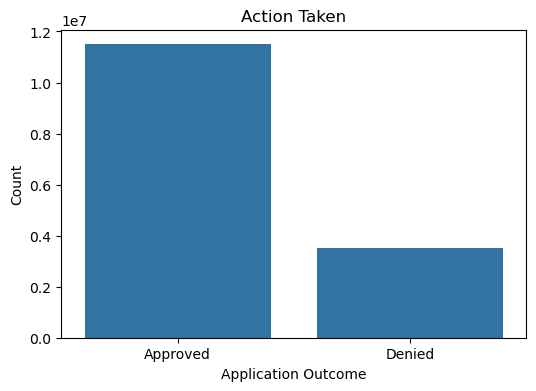

In [21]:
# View the actions taken

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'action_taken')

ax.set_xticks([0, 1])  # positions of the bars
ax.set_xticklabels(['Approved', 'Denied'])

plt.title('Action Taken')
plt.xlabel('Application Outcome')
plt.ylabel('Count')

plt.show()

In [22]:
# Calculate approval rate
counts_action = hmda.groupby("action_taken").size()

ratio_action = counts_action[1]/(counts_action[1] + counts_action[2])

print("The percentage of approvals is", round(ratio_action * 100, 2), "%", "and the percentage of denials is", round(100 - ratio_action * 100, 2), "%")

The percentage of approvals is 76.55 % and the percentage of denials is 23.45 %


### B. Loan type

In [ ]:
# View the loan types

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'loan_type')

ax.set_xticks([0, 1, 2, 3])  # positions of the bars
ax.set_xticklabels(['Conventional', 'FHA-Insured', 'VA-Guaranteed', 'FSA/RHS'])

plt.title('Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Count')

plt.show()

In [ ]:
# Count observations in each loan type category
counts_loan = hmda["loan_type"].value_counts().sort_index()

# Calculate percentages
percent_loan = counts_loan / counts_loan.sum() * 100

# Race labels
loan_labels = {
    1: "conventional",
    2: "FHA-insured",
    3: "VA-guaranteed",
    4: "FSA/RHS"
}

# Print results
for code, percentage in percent_loan.items():
    print(
        f"The percentage of {loan_labels[code]} loans is "
        f"{percentage:.2f}%"
    )

### C. Lien status

In [ ]:
# View the lien statuses

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'lien_status')

ax.set_xticks([0, 1, 2])  # positions of the bars
ax.set_xticklabels(['Secured by a first lien', 'Secured by a subordinate lien', 'Not secured by a lien'])

plt.title('Lien Status')
plt.xlabel('Lien Status')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Count')

plt.show()

In [ ]:
# Count observations in each lien status category
counts_lien = hmda["lien_status"].value_counts().sort_index()

# Calculate percentages
percent_lien = counts_lien / counts_lien.sum() * 100

# Race labels
lien_labels = {
    1: "secured by a first lien",
    2: "secured by a subordinate lien",
    3: "not secured by a lien"
}

# Print results
for code, percentage in percent_lien.items():
    print(
        f"The percentage of mortgages {lien_labels[code]} is "
        f"{percentage:.2f}%"
    )

### D. Race

In [ ]:
# View the race categories

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'race')

ax.set_xticks([0, 1, 2, 3, 4, 5])  # positions of the bars
ax.set_xticklabels(['N/A', 'American Indian or Alaska Native', 'Asian', 'Black or African American',
                    'Native Hawaiian\n or Other Pacific Islander', 'White'])

plt.title('Race')
plt.xlabel('Race')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Count')

plt.show()

In [ ]:
# Count observations in each race category
counts_race = hmda["race"].value_counts().sort_index()

# Calculate percentages
percent_race = counts_race / counts_race.sum() * 100

# Race labels
race_labels = {
    0: "did not provide race details",
    1: "identify as American Indian or Alaska Native",
    2: "identify as Asian",
    3: "identify as Black or African American",
    4: "identify as Native Hawaiian or Other Pacific Islander",
    5: "identify as White"
}

# Print results
for code, percentage in percent_race.items():
    print(
        f"The percentage of people who {race_labels[code]} is "
        f"{percentage:.2f}%"
    )

### E. Sex

In [ ]:
# View the race categories

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'sex')

ax.set_xticks([0, 1, 2])  # positions of the bars
ax.set_xticklabels(['N/A', 'Male', 'Female'])

plt.title('Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

In [ ]:
# Count observations in each sex category
counts_sex = hmda["sex"].value_counts().sort_index()

# Calculate percentages
percent_sex = counts_sex / counts_sex.sum() * 100

# Race labels
sex_labels = {
    0: "did not provide sex details",
    1: "identify as male",
    2: "identify as female"
}

# Print results
for code, percentage in percent_sex.items():
    print(
        f"The percentage of people who {sex_labels[code]} is "
        f"{percentage:.2f}%"
    )

### F. Ethnicity

In [ ]:
# View the ethnicity categories

plt.figure(figsize=(6, 4))

ax = sns.countplot(data = hmda, x = 'ethnicity')

ax.set_xticks([0, 1, 2])  # positions of the bars
ax.set_xticklabels(['N/A', 'Hispanic or Latino', 'Not Hispanic or Latino'])

plt.title('Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')

plt.show()

In [ ]:
# Count observations in each ethnicity category
counts_ethnicity = hmda["ethnicity"].value_counts().sort_index()

# Calculate percentages
percent_ethnicity = counts_ethnicity / counts_ethnicity.sum() * 100

# Race labels
ethnicity_labels = {
    0: "did not provide ethnicity details",
    1: "identify as Hispanic or Latino",
    2: "do not identify as Hispanic or Latino"
}

# Print results
for code, percentage in percent_ethnicity.items():
    print(
        f"The percentage of people who {ethnicity_labels[code]} is "
        f"{percentage:.2f}%"
    )

## 3. Multivariate variable exploration

### A. Approval outcome by sensitive group (race, sex, ethnicity), loan type, and lien status

#### i. Race

In [ ]:
# Count approvals and denials by race
race_action_counts = pd.crosstab(
    hmda["race"],
    hmda["action_taken"]
)

# Convert to percentages within each race
race_action_pct = pd.crosstab(
    hmda["race"],
    hmda["action_taken"],
    normalize="index"
) * 100

race_labels = {
    0: "Not provided",
    1: "American Indian or Alaska Native",
    2: "Asian",
    3: "Black or African American",
    4: "Native Hawaiian\n or Other Pacific Islander",
    5: "White"
}

# Display
race_action_pct = race_action_pct.round(2)
race_action_pct.index = race_action_pct.index.map(race_labels)
race_action_pct.columns = ["Approved (%)", "Denied (%)"]

race_action_pct

In [ ]:
# Stacked bar plot of approvals/denials by race

ax = race_action_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel("Percentage of Applications")
plt.xlabel("Race")
plt.title("Loan Approval and Denial Rates by Race")
plt.legend(title="Outcome", loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### ii. Sex

In [ ]:
# Count approvals and denials by sex
sex_action_counts = pd.crosstab(
    hmda["sex"],
    hmda["action_taken"]
)

# Convert to percentages within each sex
sex_action_pct = pd.crosstab(
    hmda["sex"],
    hmda["action_taken"],
    normalize="index"
) * 100

sex_labels = {
    0: "Not provided",
    1: "Male",
    2: "Female"
}

# Display
sex_action_pct = sex_action_pct.round(2)
sex_action_pct.index = sex_action_pct.index.map(sex_labels)
sex_action_pct.columns = ["Approved (%)", "Denied (%)"]

sex_action_pct

In [ ]:
# Stacked bar plot of approvals/denials by sex

ax = sex_action_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel("Percentage of Applications")
plt.xlabel("Sex")
plt.title("Loan Approval and Denial Rates by Sex")
plt.legend(title="Outcome", loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### iii. Ethnicity

In [ ]:
# Count approvals and denials by ethnicity
ethnicity_action_counts = pd.crosstab(
    hmda["ethnicity"],
    hmda["action_taken"]
)

# Convert to percentages within each ethnicity
ethnicity_action_pct = pd.crosstab(
    hmda["ethnicity"],
    hmda["action_taken"],
    normalize="index"
) * 100

ethnicity_labels = {
    0: "Not provided",
    1: "Hispanic or Latino",
    2: "Not Hispanic or Latino"
}

# Display
ethnicity_action_pct = ethnicity_action_pct.round(2)
ethnicity_action_pct.index = ethnicity_action_pct.index.map(ethnicity_labels)
ethnicity_action_pct.columns = ["Approved (%)", "Denied (%)"]

ethnicity_action_pct

In [ ]:
# Stacked bar plot of approvals/denials by ethnicity

ax = ethnicity_action_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel("Percentage")
plt.xlabel("Ethnicity")
plt.title("Loan Approval and Denial Rates by Ethnicity")
plt.legend(title="Outcome")
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha="right")
plt.show()

#### iv. Loan Types

In [ ]:
# Count approvals and denials by loan type
loan_type_action_counts = pd.crosstab(
    hmda["loan_type"],
    hmda["action_taken"]
)

# Convert to percentages within each loan type
loan_type_action_pct = pd.crosstab(
    hmda["loan_type"],
    hmda["action_taken"],
    normalize="index"
) * 100

loan_type_labels = {
    1: "Conventional",
    2: "FHA-Insured",
    3: "VA-Guaranteed",
    4: "FSA/RHS"
}

# Display
loan_type_action_pct = loan_type_action_pct.round(2)
loan_type_action_pct.index = loan_type_action_pct.index.map(loan_type_labels)
loan_type_action_pct.columns = ["Approved (%)", "Denied (%)"]

loan_type_action_pct

In [ ]:
# Stacked bar plot of approvals/denials by loan type

ax = loan_type_action_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel("Percentage")
plt.xlabel("Loan Type")
plt.title("Loan Approval and Denial Rates by Loan Type")
plt.legend(title="Outcome")
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha="right")
plt.show()

#### v. Lien Status

In [ ]:
# Count approvals and denials by lien status
lien_status_action_counts = pd.crosstab(
    hmda["lien_status"],
    hmda["action_taken"]
)

# Convert to percentages within each lien status
lien_status_action_pct = pd.crosstab(
    hmda["lien_status"],
    hmda["action_taken"],
    normalize="index"
) * 100

lien_status_labels = {
    1: "Secured by a first lien",
    2: "Secured by a subordinate lien",
    3: "Not secured by a lien"
}

# Display
lien_status_action_pct = lien_status_action_pct.round(2)
lien_status_action_pct.index = lien_status_action_pct.index.map(loan_type_labels)
lien_status_action_pct.columns = ["Approved (%)", "Denied (%)"]

lien_status_action_pct

In [ ]:
# Stacked bar plot of approvals/denials by lien status

ax = lien_status_action_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel("Percentage")
plt.xlabel("Lien Status")
plt.title("Loan Approval and Denial Rates by Lien Status")
plt.legend(title="Outcome")
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha="right")
plt.show()

A "smoke alarm" calibrated on only sex will miss the big signals.

### B. Sensitive group (race, sex, ethnicity) by time

In [ ]:
# Get approval rates by year and race

approval_rates_race = (
    hmda.assign(approved=hmda["action_taken"].eq(1))
        .groupby(["year", "race"])["approved"]
        .mean()
        .mul(100)
        .unstack()
)

approval_rates_race.columns = [
    "Not provided",
    "American Indian/Alaska Native",
    "Asian",
    "Black",
    "Native Hawaiian/Pacific Islander",
    "White"
]

In [ ]:
# Plot approval rates by year and race

plt.figure(figsize=(12, 6))

for race in approval_rates_race.columns:
    plt.plot(
        approval_rates_race.index,
        approval_rates_race[race],
        marker="o",
        label=race
    )

plt.title("Loan Approval Rate by Race (2007–2017)")
plt.xlabel("Year")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)

plt.legend(
    title="Race",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Get approval rates by year and sex

approval_rates_sex = (
    hmda.assign(approved=hmda["action_taken"].eq(1))
        .groupby(["year", "sex"])["approved"]
        .mean()
        .mul(100)
        .unstack()
)

approval_rates_sex.columns = [
    "Not provided",
    "Male",
    "Female"
]

In [ ]:
# Plot approval rates by year and sex

plt.figure(figsize=(12, 6))

for sex in approval_rates_sex.columns:
    plt.plot(
        approval_rates_sex.index,
        approval_rates_sex[sex],
        marker="o",
        label=sex
    )

plt.title("Loan Approval Rate by Sex (2007–2017)")
plt.xlabel("Year")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)

plt.legend(
    title="Sex",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Get approval rates by year and ethnicity

approval_rates_ethnicity = (
    hmda.assign(approved=hmda["action_taken"].eq(1))
        .groupby(["year", "ethnicity"])["approved"]
        .mean()
        .mul(100)
        .unstack()
)

approval_rates_ethnicity.columns = [
    "Not provided",
    "Hispanic or Latino",
    "Not Hispanic or Latino"
]

In [ ]:
# Plot approval rates by year and ethnicity

plt.figure(figsize=(12, 6))

for ethnicity in approval_rates_ethnicity.columns:
    plt.plot(
        approval_rates_ethnicity.index,
        approval_rates_ethnicity[ethnicity],
        marker="o",
        label=ethnicity
    )

plt.title("Loan Approval Rate by Ethnicity (2007–2017)")
plt.xlabel("Year")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)

plt.legend(
    title="Ethnicity",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### C. Loan type by sensitive group (race, sex, ethnicity)

### i. Race by loan type

In [ ]:
# Convert to percentages within each race and loan type
race_loan_pct = pd.crosstab(
    hmda["race"],
    hmda["loan_type"],
    normalize="index"
) * 100

In [ ]:
race_loan_pct.index = race_loan_pct.index.map(race_labels)
race_loan_pct.columns = race_loan_pct.columns.map(loan_labels)

# Plot
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    race_loan_pct,
    cmap="crest",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5
)

ax.set_title("Heatmap of Loan Type by Race")
ax.set_xlabel("Loan Type")
ax.set_ylabel("Race")

plt.tight_layout()
plt.show()

FHA loans are concentrated among minoroty borrowers, and black applicants have the lowest approval rate for "conventional" loans. The highest "conventional" loan type is Asian applicants

### ii. Sex by loan type

In [ ]:
# Convert to percentages within each sex and loan type
sex_loan_pct = pd.crosstab(
    hmda["sex"],
    hmda["loan_type"],
    normalize="index"
) * 100

In [ ]:
sex_loan_pct.index = sex_loan_pct.index.map(sex_labels)
sex_loan_pct.columns = sex_loan_pct.columns.map(loan_labels)

# Plot
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    sex_loan_pct,
    cmap="crest",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5
)

ax.set_title("Heatmap of Loan Type by Sex")
ax.set_xlabel("Loan Type")
ax.set_ylabel("Sex")

plt.tight_layout()
plt.show()

### iii. Ethnicity by loan type

In [ ]:
# Convert to percentages within each ethnicity and loan type
ethnicity_loan_pct = pd.crosstab(
    hmda["ethnicity"],
    hmda["loan_type"],
    normalize="index"
) * 100

In [ ]:
ethnicity_loan_pct.index = ethnicity_loan_pct.index.map(ethnicity_labels)
ethnicity_loan_pct.columns = ethnicity_loan_pct.columns.map(loan_labels)

# Plot
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    ethnicity_loan_pct,
    cmap="crest",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5
)

ax.set_title("Heatmap of Loan Type by Ethnicity")
ax.set_xlabel("Loan Type")
ax.set_ylabel("Ethnicity")

plt.tight_layout()
plt.show()

Race and ethnicity show systematic differences in loan type access, with minority groups — particularly Black and Hispanic applicants — disproportionately concentrated in FHA loans. Sex shows minimal structural differences except the demographically explained VA pattern. This structural difference in loan type access is part of the disparity picture, and my modelling stage will need to account for loan type as a feature to avoid it confounding my fairness metrics.

### D. Continuous variables by sensitive group (race, sex, ethnicity) and action taken

### i. Income and sensitive group/action taken

In [ ]:
# Plot income by approval rates

approval_labels = ["Approved", "Denied"]

ax = sns.violinplot(
    x = "action_taken",
    y = "log_income_000s",
    data = hmda,
    inner = "quartile",
    hue = "action_taken",
    palette = "Pastel1",
    legend = False
)

ax.set_title("Distribution of Log Applicant Income by Action Taken")
ax.set_xlabel("Action Taken")
ax.set_ylabel("Log Applicant Income (000s)")

ax.set_xticklabels(approval_labels)

plt.tight_layout()
plt.show()

In [ ]:
# Plot income by sensitive characteristics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Race
sns.violinplot(
    x = "race",
    y = "log_income_000s",
    hue = "race",
    data = hmda,
    inner = "quartile",
    palette = "Pastel1",
    legend = False,
    ax = axes[0]
)

axes[0].set_title("Income by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Log Applicant Income (000s)")

axes[0].set_xticklabels([
    "Not\nProvided",
    "AI/AN",
    "Asian",
    "Black",
    "NH/PI",
    "White"
])

# Sex
sns.violinplot(
    x = "sex",
    y = "log_income_000s",
    hue = "sex",
    data = hmda,
    inner = "quartile",
    palette = "Pastel2",
    legend = False,
    ax = axes[1]
)

axes[1].set_title("Income by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("")

axes[1].set_xticklabels([
    "Not\nProvided",
    "Male",
    "Female"
])

# Ethnicity
sns.violinplot(
    x = "ethnicity",
    y = "log_income_000s",
    hue = "ethnicity",
    data = hmda,
    inner = "quartile",
    palette = "Set3",
    legend = False,
    ax = axes[2]
)

axes[2].set_title("Income by Ethnicity")
axes[2].set_xlabel("Ethnicity")
axes[2].set_ylabel("")

axes[2].set_xticklabels([
    "Not\nProvided",
    "Hispanic",
    "Non-\nHispanic"
])

plt.tight_layout()
plt.show()

If there isn't a big difference in actions taken by income but there is by race, it means that it's unlikely that minoroty races, ceteris paribus, having less income is the driving factor behind the denials. While it's important to consider external factors like debt-to-income ratio, self selection, etc., it may also suggest systemic bias in the mortgage data.

### ii. Loan amount and sensitive group/action taken

In [ ]:
# Plot loan amounts by approval rates

approval_labels = ["Approved", "Denied"]

ax = sns.violinplot(
    x = "action_taken",
    y = "log_loan_amount_000s",
    data = hmda,
    inner = "quartile",
    hue = "action_taken",
    palette = "Pastel1",
    legend = False
)

ax.set_title("Distribution of Log Loan Amount by Action Taken")
ax.set_xlabel("Action Taken")
ax.set_ylabel("Log Loan Amount (000s)")

ax.set_xticklabels(approval_labels)

plt.tight_layout()
plt.show()

The sharp break is where the conforming loan limit is.

In [ ]:
# Plot loan amounts by sensitive characteristics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Race
sns.violinplot(
    x = "race",
    y = "log_loan_amount_000s",
    hue = "race",
    data = hmda,
    inner = "quartile",
    palette = "Pastel1",
    legend = False,
    ax = axes[0]
)

axes[0].set_title("Loan Amount by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Log Loan Amount (000s)")

axes[0].set_xticklabels([
    "Not\nProvided",
    "AI/AN",
    "Asian",
    "Black",
    "NH/PI",
    "White"
])

# Sex
sns.violinplot(
    x = "sex",
    y = "log_loan_amount_000s",
    hue = "sex",
    data = hmda,
    inner = "quartile",
    palette = "Pastel2",
    legend = False,
    ax = axes[1]
)

axes[1].set_title("Loan Amount by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("")

axes[1].set_xticklabels([
    "Not\nProvided",
    "Male",
    "Female"
])

# Ethnicity
sns.violinplot(
    x = "ethnicity",
    y = "log_loan_amount_000s",
    hue = "ethnicity",
    data = hmda,
    inner = "quartile",
    palette = "Set3",
    legend = False,
    ax = axes[2]
)

axes[2].set_title("Loan Amount by Ethnicity")
axes[2].set_xlabel("Ethnicity")
axes[2].set_ylabel("")

axes[2].set_xticklabels([
    "Not\nProvided",
    "Hispanic",
    "Non-\nHispanic"
])

plt.tight_layout()
plt.show()

Analysis of log-transformed loan amounts across demographic groups reveals a structurally important pattern related to the conforming loan limit. For most racial groups, the loan amount distribution exhibits a bimodal shape — a cluster below the Fannie Mae/Freddie Mac conforming limit of $417,000 and a secondary cluster above it — reflecting the well-documented bunching effect whereby borrowers and lenders structure loans to remain within conventional financing terms. However, this bimodal pattern is notably absent for Black and Hispanic applicants, whose loan amount distributions are concentrated in the sub-conforming range, consistent with their lower median incomes identified earlier. This suggests that the conforming loan limit — and the associated financing advantages it confers — is structurally less accessible to these groups, representing a dimension of inequality that aggregate approval rate comparisons alone do not capture.

The smoother violins (e.g. AI/AN) reflect a lack of data points.

### iii. Tract to MSA/MD income and sensitive group/action taken

In [ ]:
# Plot tract to MSA/MD income by approval rates

approval_labels = ["Approved", "Denied"]

ax = sns.violinplot(
    x = "action_taken",
    y = "log_tract_to_msamd_income",
    data = hmda,
    inner = "quartile",
    hue = "action_taken",
    palette = "Pastel1",
    legend = False
)

ax.set_title("Distribution of Log Tract to MSA/MD Income by Action Taken")
ax.set_xlabel("Action Taken")
ax.set_ylabel("Log Tract to MSA/MD Income")

ax.set_xticklabels(approval_labels)

plt.tight_layout()
plt.show()

In [ ]:
# Plot tract to MSA/MD income amounts by sensitive characteristics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Race
sns.violinplot(
    x = "race",
    y = "log_tract_to_msamd_income",
    hue = "race",
    data = hmda,
    inner = "quartile",
    palette = "Pastel1",
    legend = False,
    ax = axes[0]
)

axes[0].set_title("Tract to MSA/MD Income by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Log Tract to MSA/MD Income")

axes[0].set_xticklabels([
    "Not\nProvided",
    "AI/AN",
    "Asian",
    "Black",
    "NH/PI",
    "White"
])

# Sex
sns.violinplot(
    x = "sex",
    y = "log_tract_to_msamd_income",
    hue = "sex",
    data = hmda,
    inner = "quartile",
    palette = "Pastel2",
    legend = False,
    ax = axes[1]
)

axes[1].set_title("Tract to MSA/MD Income by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("")

axes[1].set_xticklabels([
    "Not\nProvided",
    "Male",
    "Female"
])

# Ethnicity
sns.violinplot(
    x = "ethnicity",
    y = "log_tract_to_msamd_income",
    hue = "ethnicity",
    data = hmda,
    inner = "quartile",
    palette = "Set3",
    legend = False,
    ax = axes[2]
)

axes[2].set_title("Tract to MSA/MD Income by Ethnicity")
axes[2].set_xlabel("Ethnicity")
axes[2].set_ylabel("")

axes[2].set_xticklabels([
    "Not\nProvided",
    "Hispanic",
    "Non-\nHispanic"
])

plt.tight_layout()
plt.show()

Minority races and ethnicities generally sit in lower income tracts (neighbourhoods). As tract to MSA/MD income is a determinin factor in making loan decisions, it implies that (e.g.) a black person with the same income as a white person, but who sits in a poorer neighbourhood, is more likely to be denied a mortgage.

### E. Continuous variables by continuous variables

In [ ]:
# Create a pairwise plot for all continous variables (income, loan amount, tract to MSA/MD income)

sample = hmda[
    ["log_income_000s", "log_loan_amount_000s", "log_tract_to_msamd_income"]
].sample(n=10000, random_state=42)

sns.pairplot(sample)
plt.show()

Very slight but no strong clear correlation between the three, suggesting little evidence of multicollinearity. I corroborate with the Pearson Correlation Coefficient.

In [ ]:
# Create the Pearson Correlation Matrix
pearson = hmda[
    [
        "log_income_000s",
        "log_loan_amount_000s",
        "log_tract_to_msamd_income"
    ]
].corr()

print(pearson)

In [ ]:
# Visualise the correlation matrix as a heatmap

pearson.index = [
    "Log Income",
    "Log Loan Amount",
    "Log Tract-to-MSA Income"
]

pearson.columns = [
    "Log Income",
    "Log Loan Amount",
    "Log Tract-to-MSA Income"
]

plt.figure(figsize=(8,6))
sns.heatmap(pearson, annot=True, cmap="crest", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.show()

**Summary of EDA findings:**

**Data cleaning decisions made:**

Log-transformed all three continuous variables, appending log versions and dropping raw columns
Capped income and loan amount at $5 million, dropping a negligible proportion of records
Dropped tract-to-MSA/MD income zeros
Dropped action_taken == 7, mapped action 2 to approval, creating a binary outcome variable with approximately 75/25 approval/denial split
FSA/RHS loan type excluded from approval rate analysis due to negligible sample size


**Continuous variables:**

All three are log-normally distributed after transformation
The conforming loan limit spike at $417,000 is clearly visible in loan amount, stable across 2007–2016 and rising to $424,100 in 2017 consistent with the documented FHFA policy change — independently validated from the raw data
No multicollinearity concerns — highest Pearson correlation is 0.51 between log income and log loan amount, tract-to-MSA/MD income correlates at 0.33 and 0.30 with the other two, confirming it captures a distinct dimension
Income distributions barely differ between approved and denied applicants, suggesting income alone is a weak predictor of outcomes
Loan amounts have risen steadily across 2007–2017 reflecting California house price appreciation, while applicant incomes have remained essentially flat — a widening income-to-loan-amount gap with implications for debt-to-income ratios
Tract-to-MSA/MD income ratio drifted slightly downward from 2013 onwards, possibly reflecting gentrification dynamics


**Outcome variable:**

Raw approval rates show clear and persistent disparities by race and ethnicity
Black applicants have approximately 14 percentage point lower approval rates than White applicants
Hispanic applicants have approximately 10 percentage point lower approval rates than non-Hispanic applicants
Sex shows minimal differences throughout — consistently the weakest differentiating variable across all analyses
Overall approval rates rose post-financial crisis across all groups, but relative gaps remained largely persistent — the system became more generous but not more equal in relative terms
Gap compression during the crisis is likely a selection effect from tighter underwriting standards rather than genuine fairness improvement, with gaps partially re-emerging from 2013 onwards


**Loan type:**

Conventional loans dominate at approximately 13 million records, FHA at 1.5 million, VA and FSA/RHS negligible
Black applicants have the highest FHA concentration at 16.26%, Hispanic applicants higher still at 19.69%, versus White applicants at 11.41% and Asian applicants at just 4.95%
VA loan usage is highest among Black applicants at 7.38%, likely reflecting military service demographics rather than a lending market effect
Approval rates differ substantially by loan type: conventional 77.7%, FHA 61.7%, VA 41.5% — counterintuitive given government backing, explained by applicant pool composition rather than lender risk
This creates a mediation structure: race affects loan type concentration, loan type affects approval rates, so part of the racial approval rate gap operates through loan type as an indirect channel rather than direct lender discrimination. Modelling decisions about whether to include loan type as a feature will determine whether fairness metrics capture total effects or direct effects only


**Continuous variables by sensitive group:**

Asian applicants have notably higher median incomes, higher loan amounts, and are located in wealthier tracts
Black and Hispanic applicants have lower median incomes and are concentrated below the conforming loan limit, explaining the absence of the bimodal loan amount distribution for these groups — the conforming limit financing advantage is structurally less accessible to them
Tract-to-MSA/MD income ratio shows systematic differences across racial and ethnic groups independent of individual income, capturing a residential segregation effect as a distinct dimension of disadvantage
Income and neighbourhood wealth differences across groups weaken but do not eliminate the fairness concern — income is a poor separator of approvals from denials, so racial gaps cannot be attributed primarily to legitimate income-based underwriting


**Key dissertation-relevant observations:**

The data independently validates a known regulatory change — the 2017 conforming loan limit increase — demonstrating data quality and the value of temporal analysis
Loan type mediates part of the race-outcome relationship, a structural feature invisible to approval rate metrics alone
The smoke alarm monitors drift rather than level — a persistently unfair but stable system would never trigger it. This is a meaningful limitation to address explicitly in the methodology section: "not getting worse" is statistically clean but philosophically weak, as it institutionalises baseline disparities as the acceptable reference point
The choice of which sensitive attribute to monitor matters — a system monitoring only sex would miss the far more significant disparities by race and ethnicity, directly supporting my metric selection and weighting argument
Static pre-deployment fairness assessment would have missed the temporal dynamics visible across 2007–2017, directly motivating the smoke alarm framework